<a href="https://colab.research.google.com/github/Yiiize/MSSP6070/blob/main/WeeklyModules/Week07/PARTICIPATION_ACTIVITY_Week_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import userdata
import os

github_token = userdata.get('Git_Key')
owner = 'Yiiize' # Replace with the GitHub repository owner
repository = 'MSSP6070' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
import subprocess
subprocess.run(['git', 'clone', clone_url])

# Navigate into the cloned repository directory (optional, but often useful)
os.chdir(repository)
print(f"Changed directory to: {os.getcwd()}")

Changed directory to: /content/MSSP6070/MSSP6070


In [ ]:
import pandas as pd

file_path = '/content/MSSP6070/data/InternetSales.csv'
try:
    internet_sales_df = pd.read_csv(file_path, encoding='latin-1')
    display(internet_sales_df.head())
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

/tmp/ipython-input-893624893.py:5: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  internet_sales_df = pd.read_csv(file_path, encoding='latin-1')


,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,1/19/2011,1/31/2011,1/26/2011
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,8.2205,8.2205,21.98,1.7584,0.5495,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1481.9379,1481.9379,2384.07,190.7256,59.6018,NaN,NaN,5/3/2013,5/15/2013,5/10/2013
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,10.8423,10.8423,28.99,2.3192,0.7248,NaN,NaN,5/3/2013,5/15/2013,5/10/2013


In [ ]:
internet_sales_df['OrderDate'] = pd.to_datetime(internet_sales_df['OrderDate'])
internet_sales_df['OrderYear'] = internet_sales_df['OrderDate'].dt.year
yearly_sales = internet_sales_df.groupby('OrderYear')['SalesAmount'].sum().reset_index()
display(yearly_sales)

,OrderYear,SalesAmount
0,2010,4.342104e+04
1,2011,7.075526e+06
2,2012,5.842485e+06
3,2013,1.635155e+07
4,2014,4.569472e+04


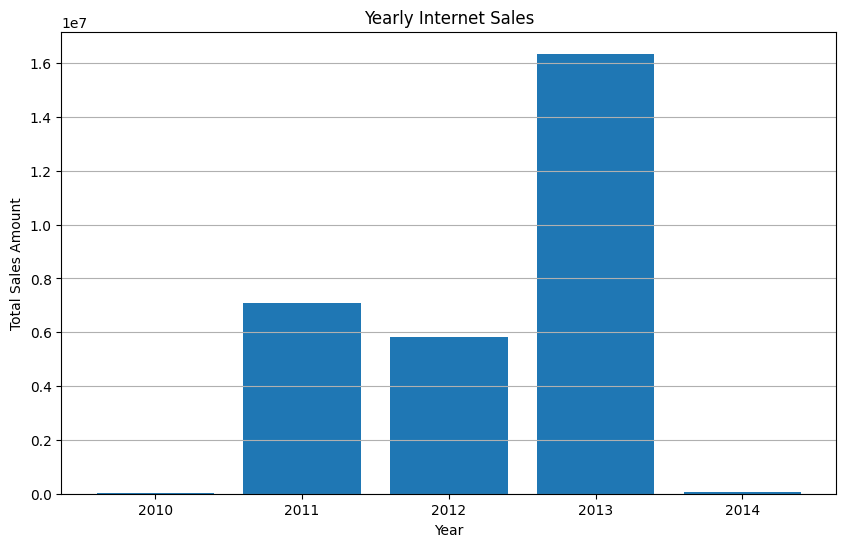

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(yearly_sales['OrderYear'], yearly_sales['SalesAmount'])
plt.xlabel('Year')
plt.ylabel('Total Sales Amount')
plt.title('Yearly Internet Sales')
plt.xticks(yearly_sales['OrderYear'])
plt.grid(axis='y')
plt.show()